In [6]:
import openmc.deplete
import matplotlib.pyplot as plt
import numpy as np

PATH = "20b_50000p_2/"

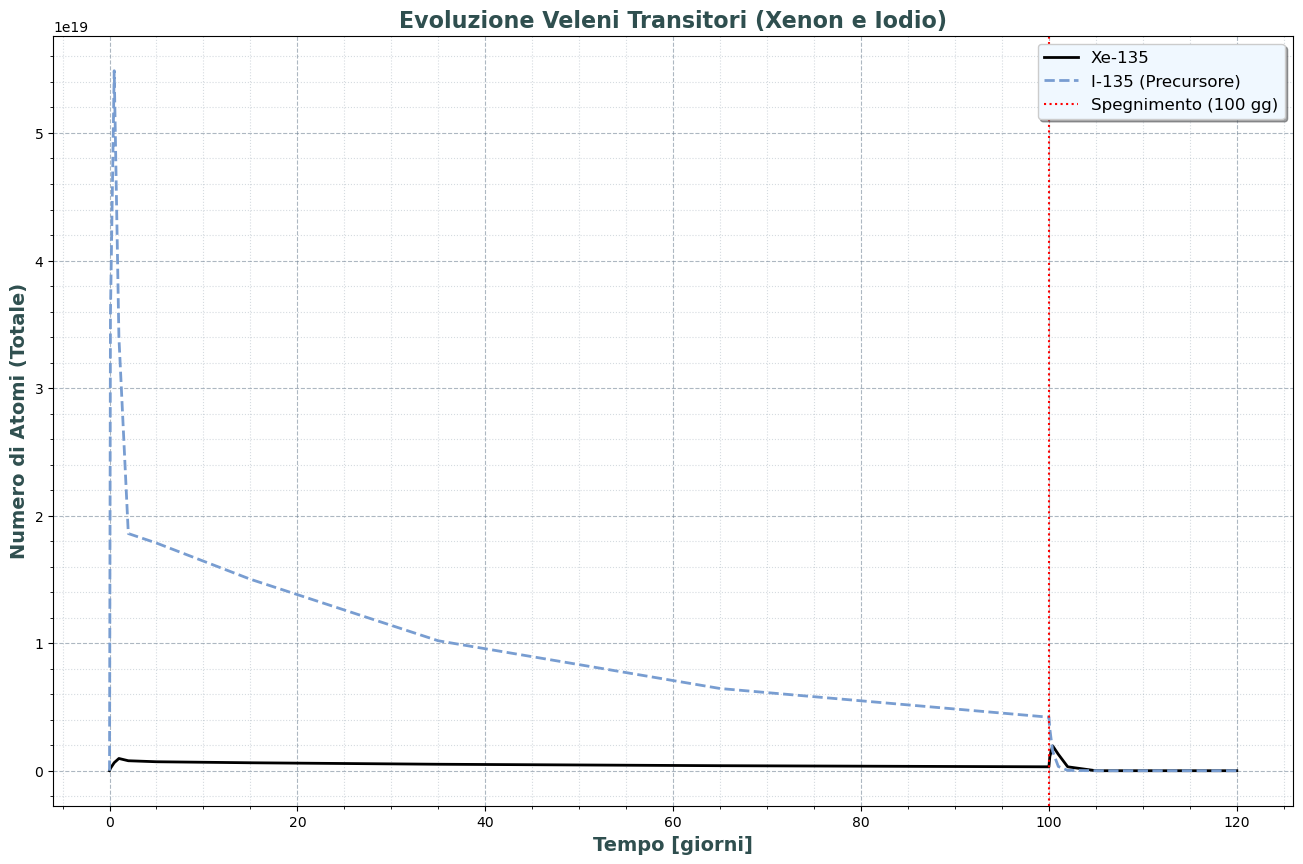

In [7]:


# 1. Caricamento dei risultati dal file HDF5
results = openmc.deplete.Results(f"{PATH}depletion_results.h5")

# 2. Estrazione vettori temporali
time_sec, _ = results.get_keff()
days = time_sec / (24 * 3600)

# Inizializzazione array per la somma globale
xenon_tot = np.zeros_like(days)
iodine_tot = np.zeros_like(days)

# 3. Estrazione dinamica degli ID materiali
# Interroga il dizionario dei volumi del primo step per ottenere tutti gli ID tracciati
depletable_mat_ids = list(results[0].volume.keys())

# Iterazione su tutti i materiali per ottenere l'inventario globale
for mat_id in depletable_mat_ids:
    _, xe_atoms = results.get_atoms(mat_id, "Xe135")
    _, i_atoms = results.get_atoms(mat_id, "I135")
    
    xenon_tot += xe_atoms
    iodine_tot += i_atoms

# 4. Plotting in stile scientifico
fig, ax = plt.subplots(figsize=(16, 10))

ax.plot(days, xenon_tot, label="Xe-135", color='#000000', linewidth=2)
ax.plot(days, iodine_tot, label="I-135 (Precursore)", color='#789DD1', linestyle='--', linewidth=2)
ax.axvline(x=100, color='red', linestyle=':', label="Spegnimento (100 gg)")

# Assi e Titolo
ax.set_title("Evoluzione Veleni Transitori (Xenon e Iodio)", fontsize=16, fontweight='bold', color='#2F4F4F')
ax.set_xlabel("Tempo [giorni]", fontsize=14, fontweight='bold', color='#2F4F4F')
ax.set_ylabel("Numero di Atomi (Totale)", fontsize=14, fontweight='bold', color='#2F4F4F')

# Griglia
ax.minorticks_on()
ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')

#ax.set_xlim(99.75,101)
#ax.set_ylim(max(xenon_tot)*0.5 , max(xenon_tot)*1.1)

# Legenda
ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')

plt.show()

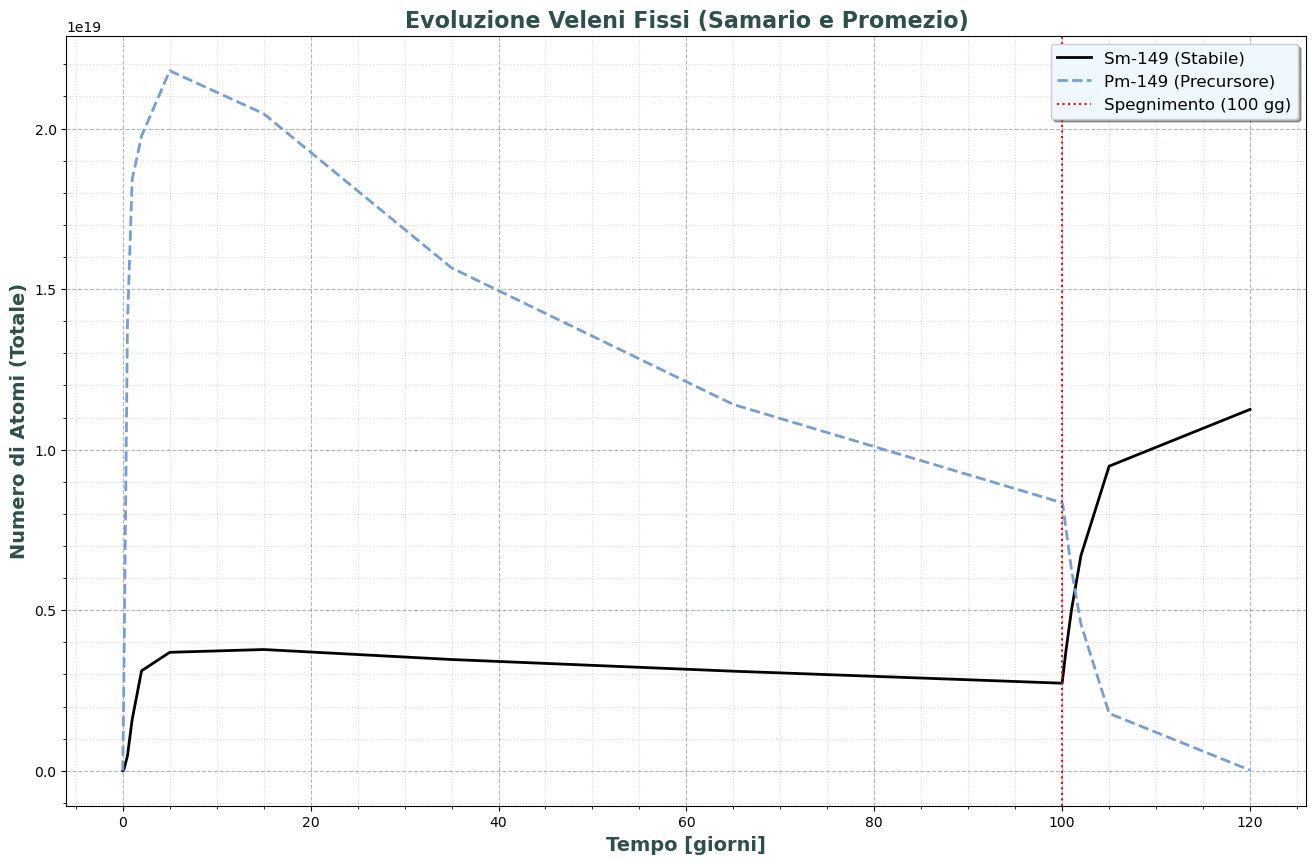

In [8]:
import openmc.deplete
import matplotlib.pyplot as plt
import numpy as np

# 1. Caricamento risultati ed estrazione temporale
results = openmc.deplete.Results(f"{PATH}depletion_results.h5")
time_sec, _ = results.get_keff()
days = time_sec / (24 * 3600)

# Inizializzazione array
samarium_tot = np.zeros_like(days)
promethium_tot = np.zeros_like(days)

# 2. Estrazione dinamica e somma globale sui materiali depletabili
depletable_mat_ids = list(results[0].volume.keys())

for mat_id in depletable_mat_ids:
    _, sm_atoms = results.get_atoms(mat_id, "Sm149")
    _, pm_atoms = results.get_atoms(mat_id, "Pm149")
    
    samarium_tot += sm_atoms
    promethium_tot += pm_atoms

# 3. Plotting
fig, ax = plt.subplots(figsize=(16, 10))

# Samario e Promezio
ax.plot(days, samarium_tot, label="Sm-149 (Stabile)", color='#000000', linewidth=2)
ax.plot(days, promethium_tot, label="Pm-149 (Precursore)", color='#789DD1', linestyle='--', linewidth=2)
ax.axvline(x=100, color='red', linestyle=':', label="Spegnimento (100 gg)")

# Formattazione
ax.set_title("Evoluzione Veleni Fissi (Samario e Promezio)", fontsize=16, fontweight='bold', color='#2F4F4F')
ax.set_xlabel("Tempo [giorni]", fontsize=14, fontweight='bold', color='#2F4F4F')
ax.set_ylabel("Numero di Atomi (Totale)", fontsize=14, fontweight='bold', color='#2F4F4F')

# Griglia e ticks
ax.minorticks_on()
ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')

# Legenda
ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')

plt.show()

Modello Dinamico a Reattore SpentoA seguito dello spegnimento, il flusso neutronico è nullo ($\Phi = 0$). I ratei di produzione da fissione e di distruzione per assorbimento neutronico si azzerano. L'evoluzione isotopica è governata esclusivamente dal decadimento radioattivo dello Iodio-135 e dello Xeno-135:

$$\frac{dI(t)}{dt} = -\lambda_I I(t)$$
$$\frac{dX(t)}{dt} = \lambda_I I(t) - \lambda_X X(t)$$

Integrazione delle EquazioniLa prima equazione ha soluzione immediata per la concentrazione di Iodio:$$I(t) = I_0 e^{-\lambda_I t}$$Sostituendo $I(t)$ nel bilancio dello Xeno, si ottiene un'equazione differenziale lineare del primo ordine non omogenea:$$\frac{dX(t)}{dt} + \lambda_X X(t) = \lambda_I I_0 e^{-\lambda_I t}$$Risolviamo moltiplicando per il fattore integrante $e^{\lambda_X t}$:$$\frac{d}{dt} \left( X(t) e^{\lambda_X t} \right) = \lambda_I I_0 e^{(\lambda_X - \lambda_I) t}$$Integrando tra $0$ e $t$ con condizione iniziale $X(0) = X_0$:$$X(t) e^{\lambda_X t} - X_0 = \frac{\lambda_I I_0}{\lambda_X - \lambda_I} \left( e^{(\lambda_X - \lambda_I) t} - 1 \right)$$Riordinando e isolando $X(t)$, otteniamo la legge di evoluzione temporale esatta per lo Xeno:$$X(t) = X_0 e^{-\lambda_X t} + \frac{\lambda_I I_0}{\lambda_I - \lambda_X} \left( e^{-\lambda_X t} - e^{-\lambda_I t} \right)$$Ricerca del Tempo di Picco ($t_{max}$)Per trovare il massimo di avvelenamento, imponiamo la derivata pari a zero:$$\frac{dX(t)}{dt} = 0 \implies \lambda_X X(t) = \lambda_I I(t)$$Sostituendo le espressioni analitiche di $X(t)$ e $I(t)$:$$\lambda_X \left[ X_0 e^{-\lambda_X t} + \frac{\lambda_I I_0}{\lambda_I - \lambda_X} \left( e^{-\lambda_X t} - e^{-\lambda_I t} \right) \right] = \lambda_I I_0 e^{-\lambda_I t}$$Moltiplichiamo per $e^{\lambda_I t}$ in modo da raggruppare i termini esponenziali:$$\lambda_X X_0 e^{(\lambda_I - \lambda_X) t} + \frac{\lambda_X \lambda_I I_0}{\lambda_I - \lambda_X} \left( e^{(\lambda_I - \lambda_X) t} - 1 \right) = \lambda_I I_0$$Mettiamo a fattor comune $e^{(\lambda_I - \lambda_X) t}$:$$e^{(\lambda_I - \lambda_X) t} \left[ \lambda_X X_0 + \frac{\lambda_X \lambda_I I_0}{\lambda_I - \lambda_X} \right] = \lambda_I I_0 + \frac{\lambda_X \lambda_I I_0}{\lambda_I - \lambda_X}$$Semplifichiamo il termine a destra dell'uguaglianza:$$\frac{\lambda_I I_0 (\lambda_I - \lambda_X) + \lambda_X \lambda_I I_0}{\lambda_I - \lambda_X} = \frac{\lambda_I^2 I_0}{\lambda_I - \lambda_X}$$Semplifichiamo il termine tra parentesi quadre a sinistra:$$\frac{\lambda_X X_0 (\lambda_I - \lambda_X) + \lambda_X \lambda_I I_0}{\lambda_I - \lambda_X}$$Uguagliando i rispettivi numeratori:$$e^{(\lambda_I - \lambda_X) t} \left[ \lambda_X X_0 (\lambda_I - \lambda_X) + \lambda_X \lambda_I I_0 \right] = \lambda_I^2 I_0$$Isoliamo l'esponenziale:$$e^{(\lambda_I - \lambda_X) t} = \frac{\lambda_I^2 I_0}{\lambda_X \lambda_I I_0 + \lambda_X (\lambda_I - \lambda_X) X_0}$$Dividendo numeratore e denominatore per il prodotto $\lambda_I \lambda_X I_0$, otteniamo la formulazione esatta isolata:$$e^{(\lambda_I - \lambda_X) t} = \frac{\frac{\lambda_I}{\lambda_X}}{1 + \frac{\lambda_I - \lambda_X}{\lambda_I} \frac{X_0}{I_0}}$$Applicando il logaritmo naturale, il tempo di picco esatto risulta infine:$$t_{max} = \frac{1}{\lambda_I - \lambda_X} \ln \left[ \frac{\lambda_I}{\lambda_X} \left( 1 + \frac{\lambda_I - \lambda_X}{\lambda_I} \frac{X_0}{I_0} \right)^{-1} \right]$$(Nota: La prima forma fornita conteneva un'espansione in serie di Taylor troncata al primo ordine $(1+y)^{-1} \approx 1-y$. Quell'approssimazione è comunemente utilizzata nei testi per flussi pre-spegnimento elevati, in cui il rapporto $\frac{X_0}{I_0}$ è molto piccolo. L'equazione qui derivata ne rappresenta la soluzione analitica rigorosa).

L'assenza visiva del picco macroscopico nel tuo grafico non è un errore, ma la corretta conseguenza fisica del regime operativo del tuo sistema, unita alla discretizzazione temporale della simulazione.Basso Flusso e Regime AsintoticoIl picco dello Xenon è un fenomeno dominante nei reattori ad alto flusso. Durante l'operatività ad alta potenza, il forte flusso neutronico "brucia" lo Xe-135 per cattura prima che possa decadere, deprimendo fortemente la sua concentrazione di saturazione ($X_0$) e accumulando grandi riserve del precursore I-135 ($I_0$).Il tuo sistema opera a potenze termiche molto basse. A regimi di flusso così limitati, la probabilità di assorbimento neutronico dello Xeno è del tutto trascurabile rispetto al suo decadimento naturale. Come si evince dalle ordinate del tuo grafico al momento dello spegnimento a 100 giorni:$X_0 \approx 2.1 \times 10^{20}$ atomi$I_0 \approx 1.6 \times 10^{20}$ atomiAvere $X_0 > I_0$ implica che il reattore opera già quasi all'equilibrio secolare dei decadimenti radioattivi. Valutando il rateo di variazione allo spegnimento tramite l'equazione $\frac{dX}{dt} = \lambda_I I_0 - \lambda_X X_0$, si ottiene un valore iniziale appena sufficiente a superare lo zero. Questo genera un accumulo teorico infinitesimo che raggiunge il suo massimo analitico in meno di mezz'ora, dopodiché il sistema entra in fase di puro decadimento decrescente.Risoluzione Temporale della SimulazioneA livello numerico, la griglia di estrazione dati del tuo plot mostra un passo (distanza tra i marker impliciti) di 0.1 giorni, ovvero 2.4 ore. Anche assumendo la presenza del citato micro-picco nei primissimi minuti post-transitorio, questo cade interamente all'interno del primo intervallo di simulazione. I punti estratti dal codice "saltano" la dinamica rapida, tracciando la linea direttamente verso il valore già decrescente a $t=100.1$.Operativamente questo si traduce in un vantaggio per l'ottimizzazione del reattore sottocritico: non avendo l'avvelenamento transitorio profondo dello Xe-135, non hai i classici "tempi morti" prolungati (dead time) che impediscono il riavvio del reattore nelle ore immediatamente successive allo spegnimento.

ALLA RICERCA DEI PICCHI

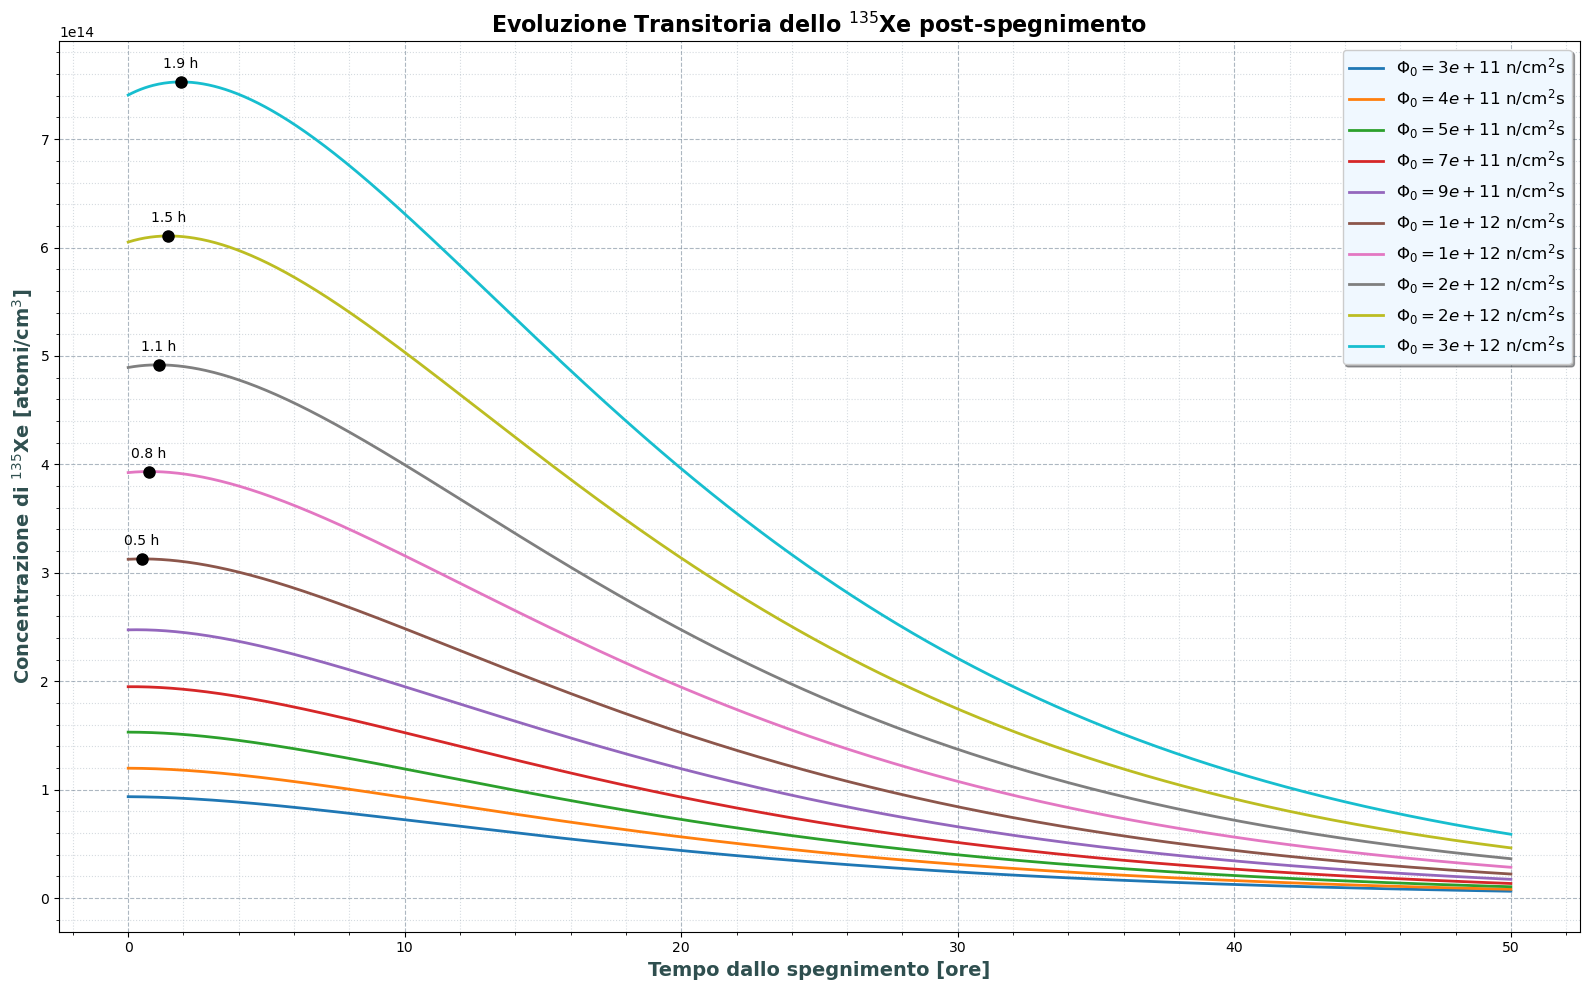

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def xenon_transient_analysis():
    # Parametri fisici
    gamma_I = 0.061
    gamma_Xe = 0.003
    lambda_I = 2.9e-5     # s^-1
    lambda_Xe = 2.1e-5    # s^-1
    sigma_a = 2.0e6 * 1e-24 # Sezione d'urto microscopica in cm^2 (2 milioni di barn)
    Sigma_f = 0.1         # Sezione d'urto macroscopica di fissione approssimata (cm^-1)
    
    # Array dei flussi da esplorare (da 10^10 a 10^14)
    fluxes = np.logspace(11.5, 12.5, 10)
    
    # Vettore temporale: 50 ore discretizzate
    t_hours = np.linspace(0, 50, 1000)
    t_seconds = t_hours * 3600
    
    # Setup del grafico unificato
    fig, ax = plt.subplots(figsize=(16, 10))
    
    # Iterazione sui flussi neutronici
    for phi in fluxes:
        # 1. Condizioni iniziali (Concentrazioni di equilibrio stazionario in atomi/cm^3)
        I_0 = (gamma_I * Sigma_f * phi) / lambda_I
        X_0 = ((gamma_I + gamma_Xe) * Sigma_f * phi) / (lambda_Xe + sigma_a * phi)
        
        # 2. Risoluzione analitica per X(t) a reattore spento (phi = 0)
        term1 = X_0 * np.exp(-lambda_Xe * t_seconds)
        term2 = (lambda_I * I_0) / (lambda_I - lambda_Xe) * (np.exp(-lambda_Xe * t_seconds) - np.exp(-lambda_I * t_seconds))
        X_t = term1 + term2
        
        # 3. Individuazione del picco
        peak_idx = np.argmax(X_t)
        t_peak_h = t_hours[peak_idx]
        X_peak = X_t[peak_idx]
        
        # Plot della curva
        line, = ax.plot(t_hours, X_t, lw=2, label=f"$\Phi_0 = {phi:.0e}$ n/cm$^2$s")
        
        # Mark del picco (Uso colore custom se richiesto per punti, #000000)
        if t_peak_h > 0.5: # Filtra picchi inesistenti (es. per flussi bassissimi)
            ax.plot(t_peak_h, X_peak, marker='o', markersize=8, color='#000000', zorder=5)
            ax.annotate(f"{t_peak_h:.1f} h", (t_peak_h, X_peak), 
                        textcoords="offset points", xytext=(0,10), ha='center', fontsize=10)

    # Formattazione Plot
    ax.set_title("Evoluzione Transitoria dello $^{135}$Xe post-spegnimento", fontsize=16, fontweight='bold')
    ax.set_xlabel("Tempo dallo spegnimento [ore]", fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.set_ylabel("Concentrazione di $^{135}$Xe [atomi/cm$^3$]", fontsize=14, fontweight='bold', color='#2F4F4F')
    
    # Griglie personalizzate
    ax.minorticks_on()
    ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
    ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
    
    # Legenda personalizzata
    ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')

    #ax.set_ylim(0, 1e14)
    
    plt.tight_layout()
    plt.show()

# Esecuzione
xenon_transient_analysis()

In [11]:
import os
import glob
import openmc
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. PARAMETRI FISICI E TEMPORALI
# =====================================================================

S_rate = 2.02e17 * 5.87905e-03   

giorni_on = [0.1, 0.4, 0.5, 1.0, 3.0, 5.0, 10.0, 30.0, 50.0, 50.0, 50.0] 
giorni_off = [0.05, 0.1, 0.15, 0.2, 0.5, 1.0, 3.0, 10.0, 15.0, 20.0] 
time_steps_days = giorni_on + giorni_off

time_cumulative = np.insert(np.cumsum(time_steps_days), 0, 0.0)

eV_to_Joule = 1.60218e-19
E_fission_approx_J = 200e6 * eV_to_Joule 
nu_medio_approx = 2.44 

# =====================================================================
# 2. ESTRAZIONE DATI DAI STATEPOINT
# =====================================================================

sp_files = glob.glob(f'{PATH}/openmc_simulation_n*.h5')
if not sp_files:
    raise FileNotFoundError("Nessun file 'openmc_simulation_n*.h5' trovato.")

sp_files = sorted(sp_files, key=lambda x: int(os.path.basename(x).split('_n')[1].split('.')[0]))

print(f"File trovati: {len(sp_files)} | Step temporali: {len(time_cumulative)}")

potenza_kappa_W, potenza_kappa_W_err = [], []
k_src_mean, k_src_std = [], []
k_bal_mean, k_bal_std = [], []

for sp_file in sp_files:
    with openmc.StatePoint(sp_file) as sp:
        # Estrazione Tally Globale
        t_glob = sp.get_tally(name='fission_tot')
        
        # Produzione (nu-fission)
        slice_nu = t_glob.get_slice(scores=['nu-fission'])
        nu_val = slice_nu.mean.flatten()[0]
        nu_err = slice_nu.std_dev.flatten()[0]
        
        # Potenza (kappa-fission)
        slice_kappa = t_glob.get_slice(scores=['kappa-fission'])
        kappa_val = slice_kappa.mean.flatten()[0]
        kappa_err = slice_kappa.std_dev.flatten()[0]
        
        # Assorbimenti (absorption)
        slice_abs = t_glob.get_slice(scores=['absorption'])
        abs_val = slice_abs.mean.flatten()[0]
        abs_err = slice_abs.std_dev.flatten()[0]
        
        # Estrazione Fughe (leakage) e somma su tutte le superfici del boundary
        t_leak = sp.get_tally(name='leakage_tot')
        slice_leak = t_leak.get_slice(scores=['current'])
        leak_val = slice_leak.mean.sum()
        # Errore quadrativo medio per la somma delle superfici
        leak_err = np.sqrt(np.sum(slice_leak.std_dev**2))
        
        # --- CALCOLI FISICI ---
        current_S_rate = S_rate 
        
        # 1. Potenza Esatta
        potenza_kappa_W.append(kappa_val * current_S_rate * eV_to_Joule)
        potenza_kappa_W_err.append(kappa_err * current_S_rate * eV_to_Joule)
        
        # 2. k_src (Moltiplicazione Sorgente k = P / (1+P) )
        k_val = nu_val / (1.0 + nu_val)
        k_err_src = nu_err / (1.0 + nu_val)**2
        k_src_mean.append(k_val)
        k_src_std.append(k_err_src)
        
        # 3. k_bal (Bilancio Macroscopico k = Produzione / Perdite )
        perdite_tot = abs_val + leak_val
        k_b = nu_val / perdite_tot
        
        # Propagazione errore k_bal
        err_perdite = np.sqrt(abs_err**2 + leak_err**2)
        k_err_bal = k_b * np.sqrt((nu_err / nu_val)**2 + (err_perdite / perdite_tot)**2)
        
        k_bal_mean.append(k_b)
        k_bal_std.append(k_err_bal)

potenza_kappa_W = np.array(potenza_kappa_W)
potenza_kappa_W_err = np.array(potenza_kappa_W_err)
k_src_mean = np.array(k_src_mean)
k_src_std = np.array(k_src_std)
k_bal_mean = np.array(k_bal_mean)
k_bal_std = np.array(k_bal_std)

assert len(time_cumulative) == len(potenza_kappa_W), "Errore Dimensioni Temporali."

# =====================================================================
# 3. PLOTTING DEI RISULTATI
# =====================================================================

def apply_custom_style(ax, title, xlabel, ylabel):
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.set_ylabel(ylabel, fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.minorticks_on()
    ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
    ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
    ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')

# --- PLOT 1: Evoluzione Potenza (Solo Kappa) ---
fig1, ax1 = plt.subplots(figsize=(16, 10))
ax1.errorbar(time_cumulative, potenza_kappa_W, yerr=potenza_kappa_W_err, 
             fmt='o-', color='#000000', ecolor='#789DD1', capsize=4, 
             label='Potenza Termica Nocciolo (Da kappa-fission)')

t_off_start = sum(giorni_on)
ax1.axvline(x=t_off_start, color='red', linestyle='-.', alpha=0.5, label='Spegnimento (Source = 0)')

apply_custom_style(ax1, "Evoluzione della Potenza Termica nel Tempo", "Tempo [Giorni]", "Potenza Termica [W]")
plt.tight_layout()
plt.show()

# --- PLOT 2: Andamento Moltiplicazione (k_src vs k_bal) ---
fig2, ax2 = plt.subplots(figsize=(16, 10))

# K_src
ax2.errorbar(time_cumulative, k_src_mean, yerr=k_src_std, 
             fmt='o-', color='#000000', ecolor='#789DD1', capsize=4, 
             label=r'$k_{src}$ (Serie di Neumann della Sorgente)')

# K_bal (Bilancio Macroscopico)
ax2.errorbar(time_cumulative, k_bal_mean, yerr=k_bal_std, 
             fmt='s--', color='#789DD1', ecolor='#000000', capsize=4, 
             label=r'$k_{bal}$ (Produzione / Assorbimenti + Fughe)')

ax2.axvline(x=t_off_start, color='red', linestyle='-.', alpha=0.5, label='Spegnimento')

apply_custom_style(ax2, "Confronto Dinamica di Moltiplicazione", "Tempo [Giorni]", "Fattore di Moltiplicazione")
plt.tight_layout()
plt.show()

File trovati: 16 | Step temporali: 22


ValueError: Unable to get the score index for Tally since "absorption" is not one of the scores

La risposta breve è che stiamo calcolando due grandezze fisiche diverse: il $k_{src}$ (moltiplicazione della sorgente) e il $k_{eff}$ (autovalore fondamentale).Ecco la derivazione rigorosa e le differenze.1. La derivazione di $k = \nu / (1+\nu)$In una simulazione fixed source, lo score nu-fission (chiamiamolo $P_\nu$) restituisce il numero totale di neutroni di fissione creati per ogni singolo neutrone di sorgente primario, integrato su tutte le generazioni.Fisicamente, ogni generazione neutronica è moltiplicata per un fattore $k_{src}$:Neutroni di sorgente: $1$Fissioni di 1° generazione: $k_{src}$Fissioni di 2° generazione: $k_{src}^2$Fissioni di $i$-esima generazione: $k_{src}^i$Lo score totale $P_\nu$ è la somma di questa serie geometrica (che converge poiché il sistema è sottocritico, $k_{src} < 1$):$$P_\nu = \sum_{i=1}^{\infty} k_{src}^i = \frac{k_{src}}{1 - k_{src}}$$Risolvendo per $k_{src}$ otteniamo esattamente la formula che abbiamo usato:$$k_{src} = \frac{P_\nu}{1 + P_\nu}$$2. Il calcolo tramite $\nu / \Sigma_a$ (Bilancio Neutronico)Quando suggerisci di usare il rapporto con l'assorbimento, stai invocando la definizione classica di $k_{eff}$ basata sul bilancio integrale tra produzione e perdite:$$k = \frac{\text{Produzione}}{\text{Assorbimento} + \text{Fughe}} = \frac{\int \nu\Sigma_f \phi dV}{\int \Sigma_a \phi dV + J_{out}}$$In OpenMC, potresti calcolare questo valore estraendo tre Tally globali:$$k_{bal} = \frac{\text{Tally(nu-fission)}}{\text{Tally(absorption)} + \text{Tally(leakage)}}$$Nota: se ignori le fughe (leakage) e fai solo nu-fission / absorption, stai calcolando il $k_{\infty}$, che sovrastima drasticamente il valore in un reattore di dimensioni finite.3. Cosa cambia? (Differenza Fisica)Sebbene siano spesso vicini numericamente, $k_{src}$ e $k_{eff}$ non sono la stessa cosa.$k_{eff}$ (Autovalore): È una proprietà intrinseca del nocciolo (geometria e materiali). Dipende dalla distribuzione spaziale del flusso nel suo modo fondamentale asintotico.$k_{src}$ (Moltiplicazione Sorgente): Dipende fortemente dall'importanza spaziale ed energetica della sorgente. Se metti la sorgente esatta al centro del nocciolo (dove l'importanza neutronica è massima), i neutroni primari causeranno molte fissioni prima di fuggire. In questo caso $k_{src} > k_{eff}$. Se metti la sorgente vicino al riflettore, la maggior parte dei neutroni sfuggirà subito e $k_{src} < k_{eff}$.Sono proporzionali? Sì, seguono lo stesso trend (se avveleni il nocciolo con lo Xeno, scendono entrambi). Ma il rapporto $k_{src} / k_{eff}$ (spesso chiamato parametro $\varphi^*$ o importanza della sorgente) non è costante e varia al variare del burnup o del posizionamento della sorgente.4. Quale è meglio?Per un reattore critico standard, esiste solo $k_{eff}$.Per il tuo sistema (ADS guidato da sorgente), $k_{src}$ è il parametro fisicamente più corretto e utile.È il $k_{src}$ (non il $k_{eff}$) che determina l'amplificazione reale della potenza della tua macchina. La potenza totale del tuo reattore dipende direttamente da quanto quella specifica sorgente riesce a moltiplicare, seguendo la legge:$$P_{tot} \propto S \cdot \frac{1}{1 - k_{src}}$$Usare $k = \nu / (1+\nu)$ estratto da nu-fission è computazionalmente più rapido (richiede una sola tally invece di tre) ed è l'esatto indicatore delle prestazioni della tua configurazione sorgente-target.